In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
import copy

import pyFLD as fld

In [2]:
# for this test we'll simulate a basic protoplanetary disk from 0.1 to 10 au, including its inner rim

In [3]:
# create a star object with some parameters
star = fld.star.Star(M=1*u.M_sun, L=1*u.L_sun)

# to create a grid, we'll first create 3 1D arrays including ghost cells and pass them to the Grid constructor
ri   = fld.grid.get_domain_with_ghosts(0.1, 10, Nx=200, log=True) * u.au
thi  = fld.grid.get_domain_with_ghosts(np.pi/2-0.3, np.pi/2+0.3, Nx=128)
phii = fld.grid.get_domain_with_ghosts(0, 2*np.pi, Nx=1)
grid = fld.grid.Grid(ri, thi, phii, geometry='spherical')

# now we create a fluid object that includes stellar irradiation from this star.

# First, create the object
Gas = fld.fluids.Gas(grid=grid, star=star, irradiation='gray', debug=False, name='basic')

# Next, this object needs a density and temperature. We can use the grid object to compute this.
# We assume an axisymmetric Gaussian profile:
R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')
H_ = 0.03 * R_ ** 1.25
rho = 3e-10 * u.g/u.cm**3 * R_ ** -1.5 * np.exp(-0.5*(z_/H_)**2)
# clip the density in the inner regions to mimic the inner rim of the disk
rho *= 1e-6 + (1-1e-6) * 0.5 * (1 - np.tanh(-(R_-0.3)/0.02))

# Now set them in the Gas object. Note that the indexing is (θ,r), but pyFLD expects (φ,θ,r):
Gas.set_density(np.ones(grid.shape) * rho)
# Gas.set_temperature(np.ones(grid.shape) * 100 * u.K * R_ ** -0.5) # starting guess
Gas.set_temperature(np.ones(grid.shape) * 50 * u.K) # starting guess

# Then, we need to set opacities. We'll set a constant value for both Rosseland and Planck
# via a function call. pyFLD expects the function to receive the fluid object:
Gas.enroll_kappaR(lambda f: 100 * u.cm**2 / u.g)
Gas.enroll_kappaP(lambda f: 100 * u.cm**2 / u.g)
Gas.enroll_kappaPstar(lambda f: 100 * u.cm**2 / u.g)

# Since we're including irradiation, we should also provide a function for the optical depth
# at the innermost radial shell of the grid. By default it's 0, so we can skip it.

# Finally, call the setup() method to compute everything else internally
Gas.setup()

# to create the context for the radiative problem, we provide the list of fluids (in this case 1)
Disk = fld.FLD.RadiativeEnvironment([Gas], verbose=True, name='disk')
Disk.configure_solver(guess=False) # as this is a quite extreme problem, this is a bit safer

# We need to tell the Disk object how to handle boundary conditions for Erad
# For this we need to set the behavior of each side: r_beg, r_end, θ_beg, θ_end, φ_beg, φ_end.
# The currently supported options are zero-gradient ("reflective") or fixed value for E_rad.
# For this problem we'll set everything to a small value of 10 K for T_rad
bounds = [fld.grid.BOUNDARY_FIXEDVALUE] * 6
vals   = [fld.tools.T_to_Er(10*u.K)] * 6
Disk.declare_boundaries(bounds, vals)

In [4]:
# Before any solving, let's plot the disk state.
# All fluids include ghost cells, which we probably don't want to plot.
# For this, we can use the slicers "act1/2/3" or "active" to select the active domain
# in 1D quantities in the x1/2/3 directions, or 3D quantities, respectively

r = grid.x1[grid.act1].to_value('au')
theta = grid.x2[grid.act2]
phi = grid.x3[grid.act3]

mid = grid.mid

def fmt(qty3D): return 1 * qty3D[grid.active][0] # take the 0th (only) element in φ

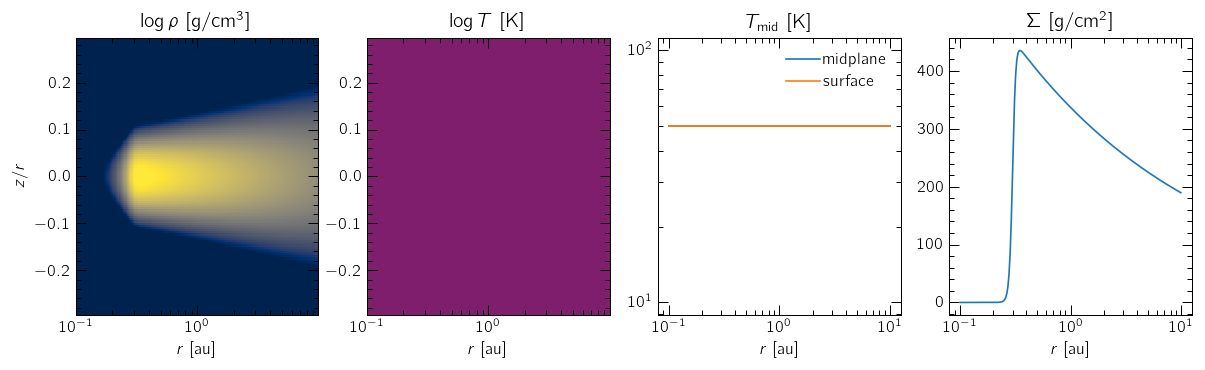

In [5]:
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[1], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [6]:
# now perform a single FLD step with a timestep of 1 year...

Disk.advance(dt=1e0 * u.yr)

RadiativeEnvironment 'disk': Converged in 0 iterations.


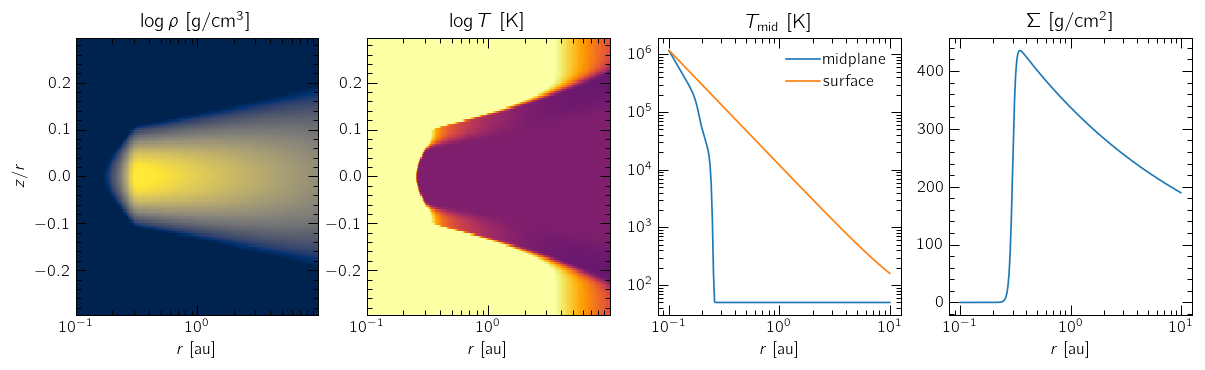

In [7]:
# ... and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane') # last index is the midplane
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[1], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [8]:
# this looks quite bad: the inner parts are reaching absurd temperatures,
# and radiation has not reached the midplane... repeat with several timesteps
for _ in range(20): Disk.advance(dt=1e0 * u.yr)

RadiativeEnvironment 'disk': Converged in 0 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 4 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 5 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iterations.
RadiativeEnvironment 'disk': Converged in 6 iter

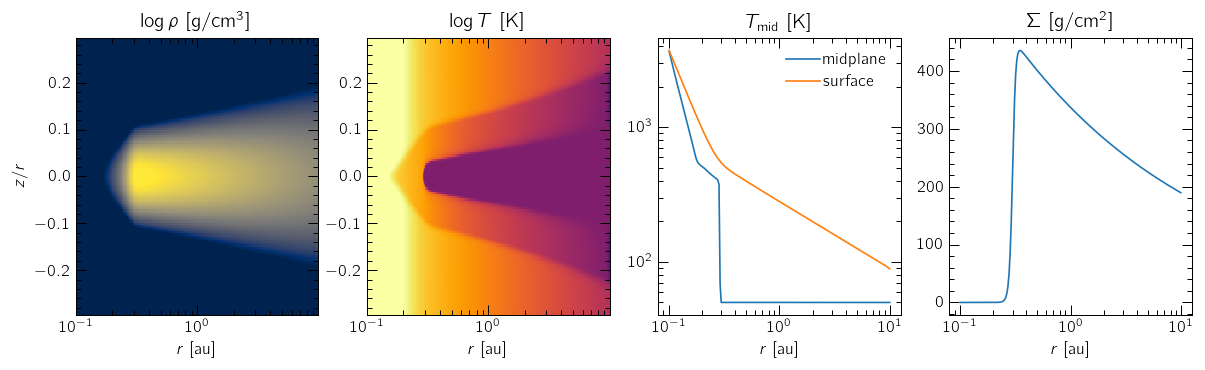

In [9]:
# ... and check the output
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane') # last index is the midplane
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[1], label='surface') # surface
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [10]:
# the temperature spikes are going away, and radiation is heading towards the midplane.
# Let's dramatically increase the timestep and iterate further

# since we have a "rough" guess for the temperature we can now let the solver
# use the previous state as the starting point. This cuts computational costs
# down by about a factor of 2 here!
Disk.configure_solver(guess=True)
for _ in range(30):
    Disk.advance(dt=1e10 * u.yr)

RadiativeEnvironment 'disk': Converged in 26 iterations.
RadiativeEnvironment 'disk': Converged in 27 iterations.
RadiativeEnvironment 'disk': Converged in 28 iterations.
RadiativeEnvironment 'disk': Converged in 30 iterations.
RadiativeEnvironment 'disk': Converged in 28 iterations.
RadiativeEnvironment 'disk': Converged in 27 iterations.
RadiativeEnvironment 'disk': Converged in 32 iterations.
RadiativeEnvironment 'disk': Converged in 23 iterations.
RadiativeEnvironment 'disk': Converged in 25 iterations.
RadiativeEnvironment 'disk': Converged in 25 iterations.
RadiativeEnvironment 'disk': Converged in 26 iterations.
RadiativeEnvironment 'disk': Converged in 28 iterations.
RadiativeEnvironment 'disk': Converged in 25 iterations.
RadiativeEnvironment 'disk': Converged in 27 iterations.
RadiativeEnvironment 'disk': Converged in 28 iterations.
RadiativeEnvironment 'disk': Converged in 28 iterations.
RadiativeEnvironment 'disk': Converged in 29 iterations.
RadiativeEnvironment 'disk': Co

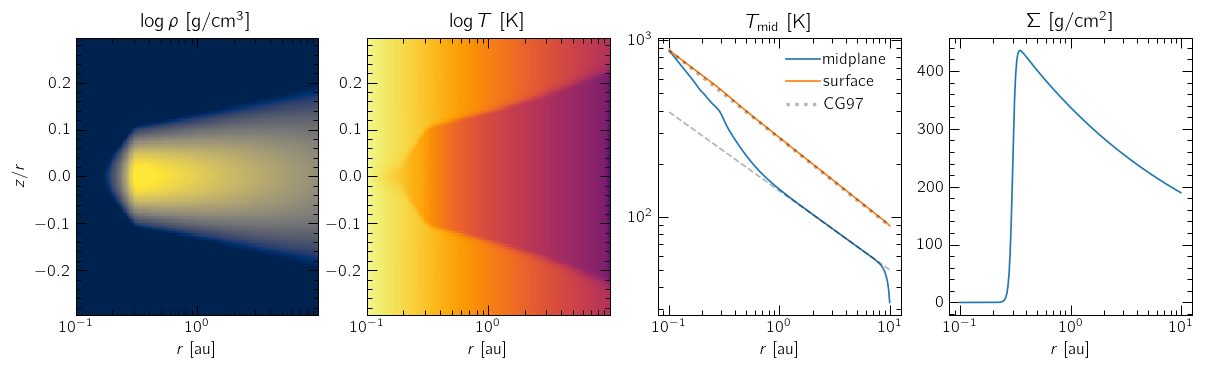

In [11]:
# ... and check the output again
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-14, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[mid], label='midplane')
ax[2].plot(r, fmt(Disk.tmp).to_value('K')[1], label='surface')
ax[3].plot(r, (fmt(Disk.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')
ax[2].plot(r, 140 * r ** -0.45, ls='--', c='k', alpha=0.3) # an eyeball fit

# Chiang Goldreich 1997 opt. thin analytical solution
TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K')
ax[2].plot(r, TCC97, ls=':', lw=2, c='k', alpha=0.3, label='CG97')

ax[2].legend()

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

In [12]:
# this looks good, but notice that the outer radial boundary drops to 10 K due to our boundary condition.
# We can improve that with a more precise boundary

Gas1 = fld.fluids.Gas(grid=grid, star=star, irradiation='gray', debug=False, name='improved')

R_ = grid.R.to_value('au')
z_ = grid.z.to_value('au')
H_ = 0.03 * R_ ** 1.25
rho = 3e-10 * u.g/u.cm**3 * R_ ** -1.5 * np.exp(-0.5*(z_/H_)**2)
rho *= 1e-6 + (1-1e-6) * 0.5 * (1 - np.tanh(-(R_-0.3)/0.02))

Gas1.set_density(np.ones(grid.shape) * rho)
# Gas1.set_temperature(np.ones(grid.shape) * 100 * u.K * R_ ** -0.5) # starting guess
Gas1.set_temperature(np.ones(grid.shape) * 50 * u.K) # starting guess
Gas1.enroll_kappaR(lambda f: 100 * u.cm**2/u.g)
Gas1.enroll_kappaP(lambda f: 100 * u.cm**2/u.g)
Gas1.enroll_kappaPstar(lambda f: 100 * u.cm**2/u.g)

# Finally, call the setup() method to compute everything else internally
Gas1.setup()
Disk1 = fld.FLD.RadiativeEnvironment([Gas1], verbose=True, name='improved')

bounds = [fld.grid.BOUNDARY_FIXEDVALUE] * 6
vals   = [fld.tools.T_to_Er(10*u.K)] * 6
vals[1] = fld.tools.T_to_Er(140*u.K * 10 ** -0.45) # outer radial boundary
Disk1.declare_boundaries(bounds, vals)

for _ in range(30): Disk1.advance(dt=1e10 * u.yr)
Disk1.configure_solver(guess=False)
# notice how it takes more iterations without using the previous state as a guess

RadiativeEnvironment 'improved': Converged in 0 iterations.
RadiativeEnvironment 'improved': Converged in 0 iterations.
RadiativeEnvironment 'improved': Converged in 51 iterations.
RadiativeEnvironment 'improved': Converged in 66 iterations.
RadiativeEnvironment 'improved': Converged in 71 iterations.
RadiativeEnvironment 'improved': Converged in 71 iterations.
RadiativeEnvironment 'improved': Converged in 75 iterations.
RadiativeEnvironment 'improved': Converged in 74 iterations.
RadiativeEnvironment 'improved': Converged in 78 iterations.
RadiativeEnvironment 'improved': Converged in 75 iterations.
RadiativeEnvironment 'improved': Converged in 78 iterations.
RadiativeEnvironment 'improved': Converged in 71 iterations.
RadiativeEnvironment 'improved': Converged in 76 iterations.
RadiativeEnvironment 'improved': Converged in 76 iterations.
RadiativeEnvironment 'improved': Converged in 79 iterations.
RadiativeEnvironment 'improved': Converged in 79 iterations.
RadiativeEnvironment 'impr

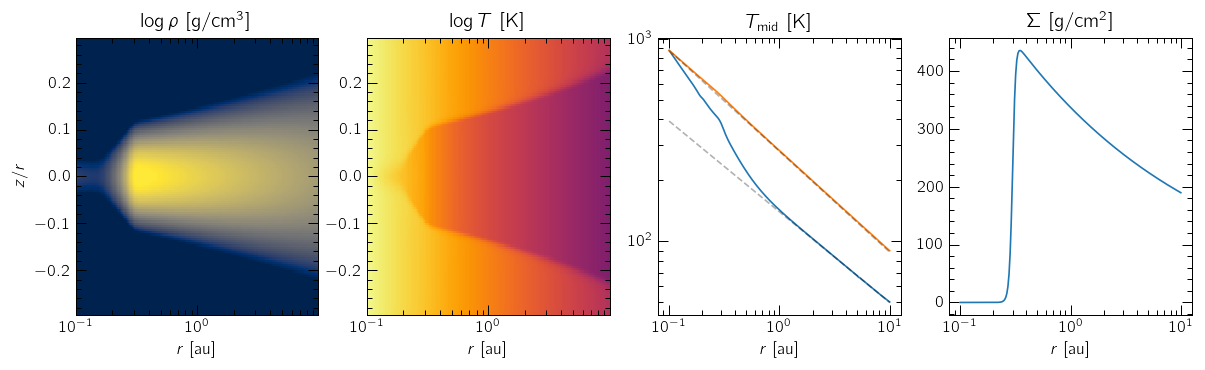

In [13]:
# ... and check the output again
fig, ax = plt.subplots(ncols=4, figsize=(12, 3), dpi=120)
ax[0].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk1.rho).to_value('g/cm3')), cmap=plt.cm.cividis, vmin=-15, vmax=-9)
ax[1].pcolormesh(r, np.cos(theta), np.log10(fmt(Disk1.tmp).to_value('K')), cmap=plt.cm.inferno, vmin=1, vmax=3)
ax[2].plot(r, fmt(Disk1.tmp).to_value('K')[mid])
ax[2].plot(r, fmt(Disk1.tmp).to_value('K')[1])
ax[3].plot(r, (fmt(Disk1.rho * grid.dz)).sum(0).to_value('g/cm2')) # surface density

for axis in ax: axis.set_xscale('log')
ax[2].set_yscale('log')
ax[2].plot(r, 140 * r ** -0.45, ls='--', c='k', alpha=0.3) # the same eyeball fit

TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K')
ax[2].plot(r, TCC97, ls='--', c='k', alpha=0.3) # Chiang Goldreich 1997 opt. thin analytical solution

for axis in ax: axis.set_xlabel(r'$r$ [au]')
ax[0].set_ylabel(r'$z/r$')
ax[0].set_title(r'$\log\rho$ [g/cm${}^3$]')
ax[1].set_title(r'$\log T$ [K]')
ax[2].set_title(r'$T_\mathrm{mid}$ [K]')
ax[3].set_title(r'$\Sigma$ [g/cm${}^2$]')

plt.show()

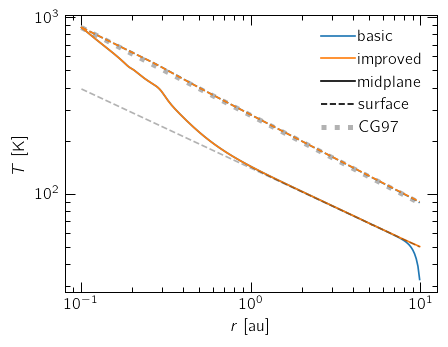

In [14]:
# let's compare the two solutions

fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
ax.plot(r, fmt(Disk.tmp).to_value('K')[mid], c='C0', ls='-', label='basic')
ax.plot(r, fmt(Disk.tmp).to_value('K')[1], c='C0', ls='--')
ax.plot(r, fmt(Disk1.tmp).to_value('K')[mid], c='C1', ls='-', label='improved')
ax.plot(r, fmt(Disk1.tmp).to_value('K')[1], c='C1', ls='--')

ax.plot(np.nan, np.nan, c='k', ls='-', label='midplane')
ax.plot(np.nan, np.nan, c='k', ls='--', label='surface')

ax.loglog()
ax.plot(r, 140 * r ** -0.45, ls='--', c='k', alpha=0.3)

TCC97 = (star.T * np.sqrt(0.5*star.R/grid.x1[grid.act1])).to_value('K')
ax.plot(r, TCC97, ls=':', c='k', lw=3, alpha=0.3, zorder=0, label='CG97')

ax.legend()

ax.set_xlabel(r'$r$ [au]')
ax.set_ylabel(r'$T$ [K]')

plt.show()